<a href="https://colab.research.google.com/github/rahsaha1059/ml_supervised_unsupervised_project/blob/main/case_study_CO2_Emission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install category_encoders

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
import category_encoders as ce
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_rainbow
import statsmodels.stats.api as sms
from decimal import Decimal

In [ ]:
input_data=pd.read_csv('CO2_Emissions.csv')

In [ ]:
input_data.shape

(7385, 12)

In [ ]:
input_data.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
input_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
input_data.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [ ]:
corr_matrix_df=input_data[['Engine Size(L)','Cylinders','Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)','Fuel Consumption Comb (L/100 km)','Fuel Consumption Comb (mpg)','CO2 Emissions(g/km)']].corr()

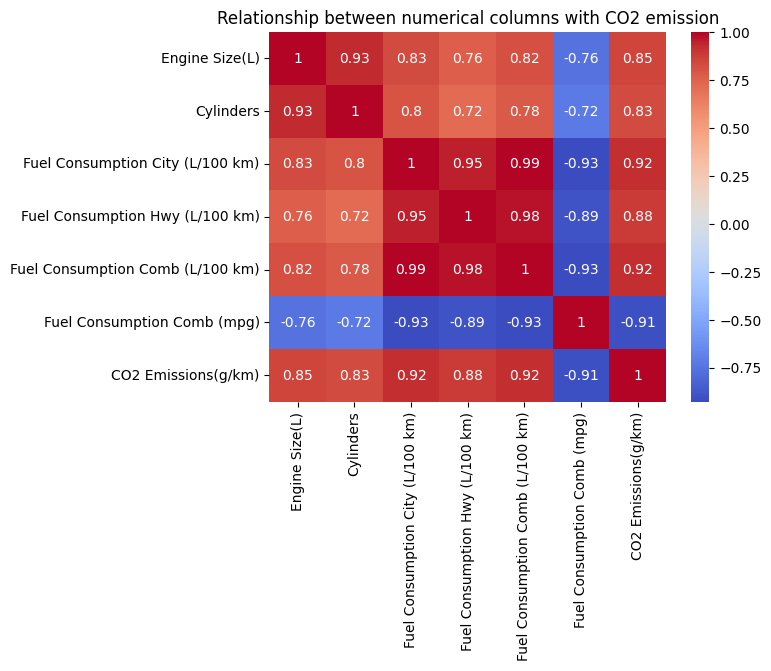

In [ ]:
sns.heatmap(corr_matrix_df,annot=True,cmap='coolwarm')
plt.title('Relationship between numerical columns with CO2 emission')
plt.show()

Correlation matrix between numerical columns and target is shown in above matrix.
It is clear that CO2 emission is highly corelated(92%) with **Fuel Consumption Comb (L/100 km)** and this feature has good coorelation (82%) with **Engine Size(L)**. So more the Engine Size and more Cylinders in a Vehicle produces more CO2 and we saw from the EDA that the Make brand BUGATTI which has the highest Cylinders and Engine Size emits CO2 the max.

In [ ]:
input_data.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221


<Axes: xlabel='Fuel Type', ylabel='CO2 Emissions(g/km)'>

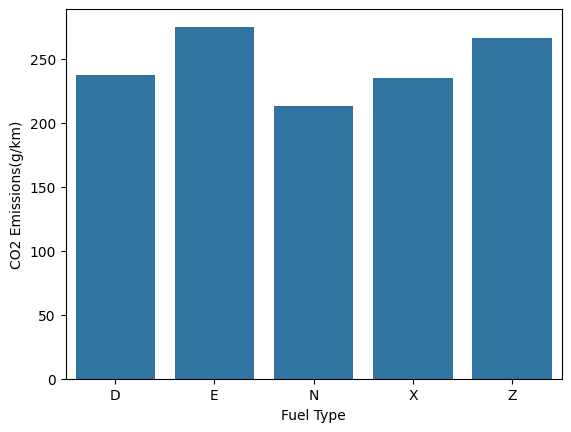

In [ ]:
# EDA
# Mean CO2 emission by Fuel Type
emission_by_fuel=input_data.groupby(['Fuel Type'])['CO2 Emissions(g/km)'].mean().reset_index()
sns.barplot(emission_by_fuel,x='Fuel Type',y='CO2 Emissions(g/km)')

The above graph shows the comparison between different fuel type vechiles average CO2 emission rate. **Fuel Type N (Natural Gas)** has the least CO2 emission(213 g/km) while **Fuel Type E (Ethanol (E85))** has highest CO2 emission rate(275 g/km).

In [ ]:
emission_by_vechclass=input_data.groupby(['Vehicle Class'])['CO2 Emissions(g/km)'].count().reset_index()
emission_by_vechclass

,Vehicle Class,CO2 Emissions(g/km)
0,COMPACT,1022
1,FULL-SIZE,639
2,MID-SIZE,1133
3,MINICOMPACT,326
4,MINIVAN,80
5,PICKUP TRUCK - SMALL,159
6,PICKUP TRUCK - STANDARD,538
7,SPECIAL PURPOSE VEHICLE,77
8,STATION WAGON - MID-SIZE,53
9,STATION WAGON - SMALL,252


/tmp/ipython-input-1404391326.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(emission_by_make,x='Make',y='CO2 Emissions(g/km)',palette=colors)


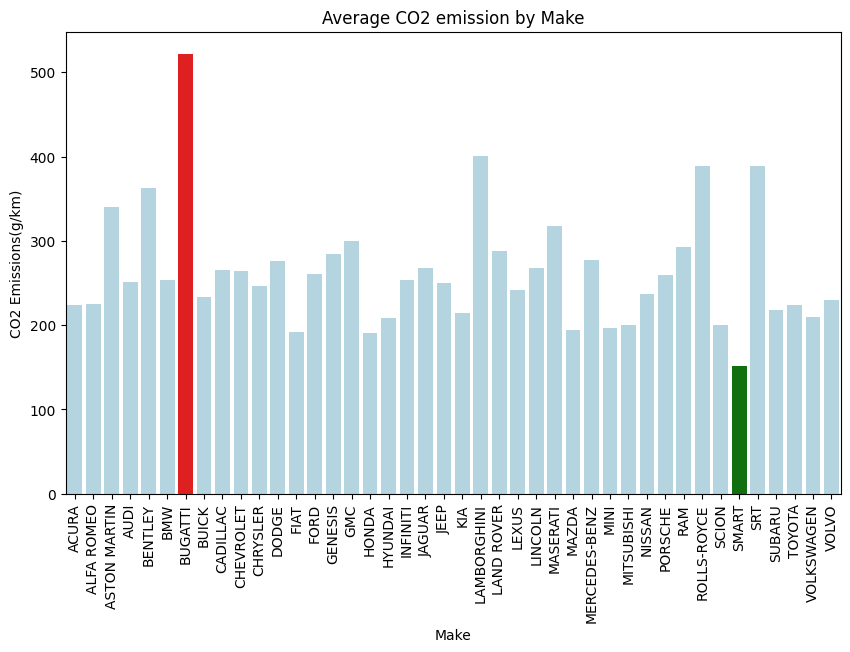

In [ ]:
emission_by_make=input_data.groupby(['Make'])['CO2 Emissions(g/km)'].mean().reset_index()
emission_by_make.sort_values(by='CO2 Emissions(g/km)',ascending=True)
plt.figure(figsize=(10,6))
max_emission=max(emission_by_make['CO2 Emissions(g/km)'])
min_emission=min(emission_by_make['CO2 Emissions(g/km)'])
colors = ["red" if v == max_emission else ("green" if v == min_emission else "lightblue") for v in emission_by_make['CO2 Emissions(g/km)']]
sns.barplot(emission_by_make,x='Make',y='CO2 Emissions(g/km)',palette=colors)
plt.title('Average CO2 emission by Make')
plt.xticks(rotation=90)
plt.show()

The above graph shows average CO2 emission by Vehicle Make.From the graph it is clear that the **highest average emission(522 g/km) is for Make brand BUGATTI** and **lowest** CO2 emission **(151 g/km)** by Make brand **SMART**

In [ ]:
# Missing Values check
input_data.isna().sum()

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


**No missing values present as seen in the above cell**

In [ ]:
input_data['Vehicle Class'].unique()

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

In [ ]:
input_data['Model'].unique()

array(['ILX', 'ILX HYBRID', 'MDX 4WD', ...,
       'Tacoma 4WD D-Cab TRD Off-Road/Pro', 'Atlas Cross Sport 4MOTION',
       'XC40 T4 AWD'], dtype=object)

In [ ]:
input_data['Make'].nunique()

42

In [ ]:
input_data['Fuel Type'].unique()

array(['Z', 'D', 'X', 'E', 'N'], dtype=object)

In [ ]:
input_data[input_data['Transmission'].str[-1]=='V'].head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
259,CHEVROLET,SPARK,SUBCOMPACT,1.2,4,AV,X,7.7,6.0,6.9,41,159
342,FORD,C-MAX HYBRID,FULL-SIZE,2.0,4,AV,X,5.6,6.4,6.0,47,138


In [ ]:
input_data[input_data['Transmission'].str[:-1] == 'AS1'].head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3492,CHEVROLET,CAMARO ZL1,SUBCOMPACT,6.2,8,AS10,Z,19.0,11.6,15.6,18,367
3656,FORD,F-150,PICKUP TRUCK - STANDARD,3.5,6,AS10,X,12.7,9.5,11.3,25,264


In [ ]:
def extract_trans_without_gears(transmission):
  extracted_trans=""
  if transmission[-2].isdigit() and transmission[-1].isdigit():
    extracted_trans=transmission[:-2]
  elif transmission[-1].isdigit():
    extracted_trans=transmission[:-1]
  else:
    extracted_trans=transmission
  return extracted_trans

In [ ]:
# derive number of gears column
input_data['Transmission_Without_Gear']=input_data['Transmission'].apply(extract_trans_without_gears)

In [ ]:
input_data.head(3)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_Without_Gear
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,AS
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,M
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,AV


In [ ]:
same_character_vech_df=input_data.groupby(['Vehicle Class','Transmission_Without_Gear','Fuel Type'])['CO2 Emissions(g/km)'].agg(['min','max']).reset_index()
same_character_vech_df['diff'] = same_character_vech_df['max'] - same_character_vech_df['min']
same_character_vech_df.sort_values(by='diff',ascending=False).head(5)

,Vehicle Class,Transmission_Without_Gear,Fuel Type,min,max,diff
139,TWO-SEATER,AM,Z,147,522,375
42,MID-SIZE,AS,Z,172,465,293
143,TWO-SEATER,M,Z,168,450,282
132,SUV - STANDARD,AS,Z,227,476,249
137,TWO-SEATER,A,Z,175,421,246


In [ ]:
input_data[(input_data['Vehicle Class']=='TWO-SEATER') & (input_data['Transmission_Without_Gear']== 'AM') & (input_data['Fuel Type']=='Z') & (input_data['CO2 Emissions(g/km)'].isin([147,522])) ]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_Without_Gear
943,SMART,FORTWO CABRIOLET,TWO-SEATER,1.0,3,AM5,Z,6.9,5.7,6.4,44,147,AM
944,SMART,FORTWO COUPE,TWO-SEATER,1.0,3,AM5,Z,6.9,5.7,6.4,44,147,AM
4509,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522,AM
5575,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522,AM
6640,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,26.8,16.6,22.2,13,522,AM


From the above 2 cells it can be seen that the **highest difference in the CO2 emission among similar characteristic vehicles** (Vehicle Class=TWO-SEATER & Transmission_Without_Gear = AM & Fuel Type = Z ) is **375 g/km (min=147 , max=522)**.
This differencce is due to Engine Size(L) and Cylinders. As it can be seen in the above cell the min emission vechile(Make = **SMART**) has the least Engine **Size(1)and Cylinders (3)** compared to Vehicle (Make=**BUGATTI**) with Engine **Size(8) and Cylinders(16)**. So Engine Size and number of Cylinders increase the fuel consumption and hence the CO2 emission rate.

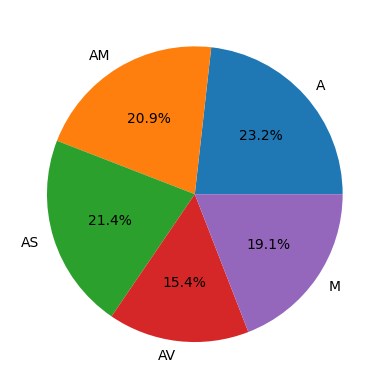

In [ ]:
emission_by_transmission=input_data.groupby(['Transmission_Without_Gear'])['CO2 Emissions(g/km)'].mean().reset_index()
plt.pie(emission_by_transmission['CO2 Emissions(g/km)'],labels=emission_by_transmission['Transmission_Without_Gear'],autopct='%1.1f%%')
plt.show()

The above graph shows that the transmission type **AV (Continuously variable)** contributes the **least** in CO2 emission while **transmission type A (Automatic)** contributes the **most** in CO2 emission.

In [ ]:
# one hot encoding for Fuel Type
onehotencoded_df=pd.get_dummies(input_data,columns=['Fuel Type','Transmission_Without_Gear'],drop_first=True,dtype=int)

In [ ]:
# drop column Transmission
onehotencoded_df.drop(columns=['Transmission'],inplace=True)

In [ ]:
# drop make , model and vehicle class columns
onehotencoded_df.drop(columns=['Make','Model','Vehicle Class'],inplace=True)

In [ ]:
onehotencoded_df.head(2)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Transmission_Without_Gear_AM,Transmission_Without_Gear_AS,Transmission_Without_Gear_AV,Transmission_Without_Gear_M
0,2.0,4,9.9,6.7,8.5,33,196,0,0,0,1,0,1,0,0
1,2.4,4,11.2,7.7,9.6,29,221,0,0,0,1,0,0,0,1


In [ ]:
X=onehotencoded_df.drop(columns=['CO2 Emissions(g/km)'])

In [ ]:
Y=onehotencoded_df[['CO2 Emissions(g/km)']]

In [ ]:
X.head(2)

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Transmission_Without_Gear_AM,Transmission_Without_Gear_AS,Transmission_Without_Gear_AV,Transmission_Without_Gear_M
0,2.0,4,9.9,6.7,8.5,33,0,0,0,1,0,1,0,0
1,2.4,4,11.2,7.7,9.6,29,0,0,0,1,0,0,0,1


In [ ]:
Y.head(2)

,CO2 Emissions(g/km)
0,196
1,221


In [ ]:
# split dataset into train and test subparts
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=34)

In [ ]:
X_train.shape

(5538, 14)

In [ ]:
Y_train.shape

(5538, 1)

In [ ]:
X_test.shape

(1847, 14)

In [ ]:
Y_test.shape

(1847, 1)

In [ ]:
# standard scaling
scaler=StandardScaler()

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)

In [ ]:
X_test_scaled=scaler.transform(X_test)

In [ ]:
# initialize LinearRegression model

lr_model=LinearRegression()

In [ ]:
lr_model.fit(X_train_scaled,Y_train)

LinearRegression()

In [ ]:
Y_test_pred=lr_model.predict(X_test_scaled)

In [ ]:
Y_train_pred=lr_model.predict(X_train_scaled)

In [ ]:
test_score=r2_score(Y_test,Y_test_pred)

In [ ]:
train_score=r2_score(Y_train,Y_train_pred)

In [ ]:
rmse= root_mean_squared_error(Y_train,Y_train_pred)
round(rmse,2)

4.81

In [ ]:
print(f"test_score={test_score} , train_score={train_score}")

test_score=0.9901683572978096 , train_score=0.9931095040686293


In [ ]:
# model evaluation
if (train_score - test_score) >0.05:
  print("The model may be overfiting")
else:
  print("It is the bestfit model")

It is the bestfit model


In [ ]:
feature_score=pd.DataFrame({
    'feature': X_train.columns,
    'coeficient': [ round(Decimal(str(x)),2) for x in np.abs(lr_model.coef_[0,:])]
})
feature_score.sort_values(by='coeficient',ascending=False)

,feature,coeficient
6,Fuel Type_E,29.81
4,Fuel Consumption Comb (L/100 km),24.89
2,Fuel Consumption City (L/100 km),21.31
9,Fuel Type_Z,15.28
8,Fuel Type_X,15.11
3,Fuel Consumption Hwy (L/100 km),11.42
5,Fuel Consumption Comb (mpg),6.18
1,Cylinders,1.73
0,Engine Size(L),0.45
10,Transmission_Without_Gear_AM,0.21


In [ ]:
corr_matrix_df= pd

**Model Evaluation:**
1. RMSE - 4.81 (mean error of 4.81 g/km CO2 emission)
2. R2_SCORE(Test data) - 99.01%
3. R2_SCORE (Train data) - 99.31%

**Check Outliers**



In [ ]:
train_features=['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)','CO2 Emissions(g/km)']
train_features

['Engine Size(L)',
 'Cylinders',
 'Fuel Consumption City (L/100 km)',
 'Fuel Consumption Hwy (L/100 km)',
 'Fuel Consumption Comb (L/100 km)',
 'Fuel Consumption Comb (mpg)',
 'CO2 Emissions(g/km)']

In [ ]:
for feature in train_features:
  q1=input_data[feature].quantile(0.25)
  q3=input_data[feature].quantile(0.75)
  iqr=q3-q1
  UL=q3+1.5*iqr
  LL=q1-1.5*iqr

  print(f"{feature},{ input_data[(input_data[feature] > UL) | (input_data[feature] < LL)].count()[feature]}")

Engine Size(L),137
Cylinders,196
Fuel Consumption City (L/100 km),132
Fuel Consumption Hwy (L/100 km),208
Fuel Consumption Comb (L/100 km),142
Fuel Consumption Comb (mpg),114
CO2 Emissions(g/km),80


In [ ]:
input_data['CO2 Emissions(g/km)'].describe()

,CO2 Emissions(g/km)
count,7385.000000
mean,250.584699
std,58.512679
min,96.000000
25%,208.000000
50%,246.000000
75%,288.000000
max,522.000000


In [ ]:
input_data['Fuel Consumption Hwy (L/100 km)'].describe()

,Fuel Consumption Hwy (L/100 km)
count,7385.000000
mean,9.041706
std,2.224456
min,4.000000
25%,7.500000
50%,8.700000
75%,10.200000
max,20.600000


In [ ]:
input_data[train_features].corr()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.927653,0.831379,0.761526,0.817060,-0.757854,0.851145
Cylinders,0.927653,1.000000,0.800702,0.715252,0.780534,-0.719321,0.832644
Fuel Consumption City (L/100 km),0.831379,0.800702,1.000000,0.948180,0.993810,-0.927059,0.919592
Fuel Consumption Hwy (L/100 km),0.761526,0.715252,0.948180,1.000000,0.977299,-0.890638,0.883536
Fuel Consumption Comb (L/100 km),0.817060,0.780534,0.993810,0.977299,1.000000,-0.925576,0.918052
Fuel Consumption Comb (mpg),-0.757854,-0.719321,-0.927059,-0.890638,-0.925576,1.000000,-0.907426
CO2 Emissions(g/km),0.851145,0.832644,0.919592,0.883536,0.918052,-0.907426,1.000000


<Axes: ylabel='Fuel Consumption Comb (L/100 km)'>

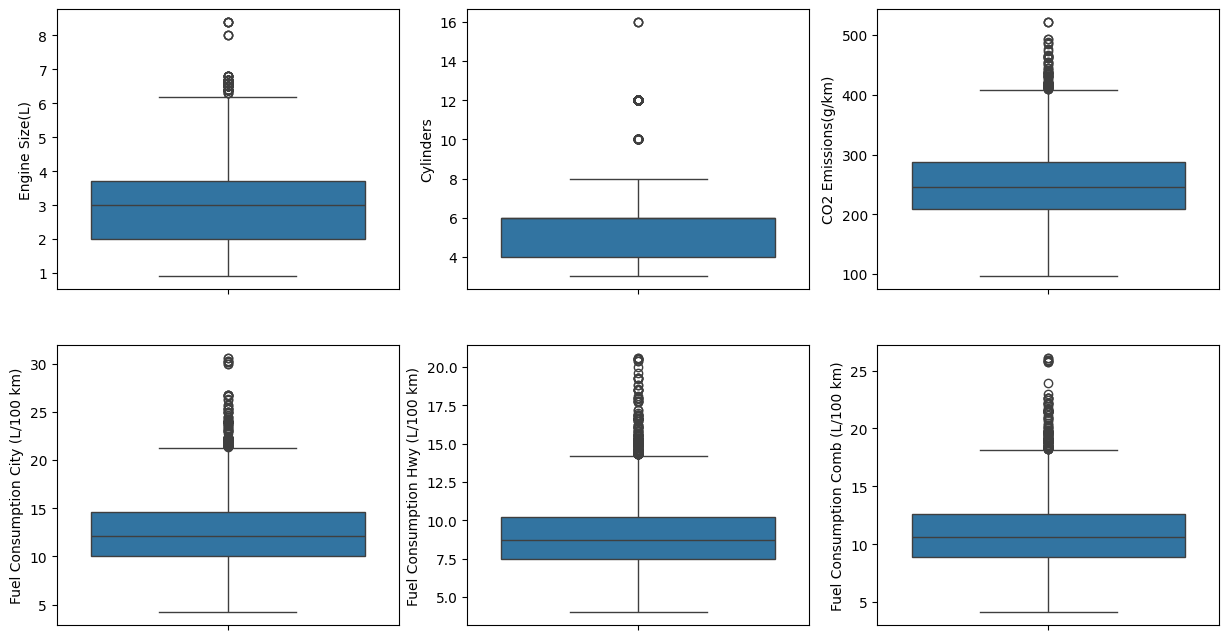

In [ ]:
# outlier vizualization
fig,axes=plt.subplots(2,3,figsize=(15,8))
sns.boxplot(y='Engine Size(L)', data= input_data, ax=axes[0,0])
sns.boxplot(y='Cylinders',data=input_data,ax=axes[0,1])
sns.boxplot(y='CO2 Emissions(g/km)',data=input_data,ax=axes[0,2])
sns.boxplot(y='Fuel Consumption City (L/100 km)',data=input_data,ax=axes[1,0])
sns.boxplot(y='Fuel Consumption Hwy (L/100 km)',data=input_data,ax=axes[1,1])
sns.boxplot(y='Fuel Consumption Comb (L/100 km)',data=input_data,ax=axes[1,2])

In [ ]:
input_data.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)',
       'Transmission_Without_Gear'],
      dtype='object')

In [ ]:
# unique number of columns for catagorical columns
cat_cols=['Make', 'Model', 'Vehicle Class','Transmission']
for i in cat_cols:
  print(i,input_data[i].nunique())

Make 42
Model 2053
Vehicle Class 16
Transmission 27


In [ ]:
# drop Transmission as a new column(Transmission_Without_Gear) is derived out of it which removes number of gears
input_data_copy=input_data.drop(['Transmission'],axis=1)
input_data_copy.columns
# target encode for Make , Model , Vehicle Class


Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Fuel Type', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)',
       'Transmission_Without_Gear'],
      dtype='object')

In [ ]:
# one-hot encoding for - Fuel Type , Transmission_Without_Gear
input_data_copy=pd.get_dummies(input_data_copy,columns=['Fuel Type','Transmission_Without_Gear'],drop_first=True,dtype=int)

In [ ]:
input_data_copy.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Transmission_Without_Gear_AM,Transmission_Without_Gear_AS,Transmission_Without_Gear_AV,Transmission_Without_Gear_M
0,ACURA,ILX,COMPACT,2.0,4,9.9,6.7,8.5,33,196,0,0,0,1,0,1,0,0
1,ACURA,ILX,COMPACT,2.4,4,11.2,7.7,9.6,29,221,0,0,0,1,0,0,0,1


In [ ]:
# split dependent and independent feature
X_ols=input_data_copy.drop('CO2 Emissions(g/km)',axis=1)
Y_ols=input_data_copy[['CO2 Emissions(g/km)']]


In [ ]:
# split into train test dataset
X_ols_train,X_ols_test,Y_ols_train,Y_ols_test=train_test_split(X_ols,Y_ols,test_size=0.25,random_state=1)

In [ ]:
X_ols_train.shape

(5538, 17)

In [ ]:
X_ols_test.shape

(1847, 17)

In [ ]:
# apply target encoding on train data first and then on test data
encoder=ce.TargetEncoder(cols=['Make','Model','Vehicle Class'])
X_ols_train_encoded=encoder.fit_transform(X_ols_train,Y_ols_train)
X_ols_test_encoded=encoder.transform(X_ols_test)

In [ ]:
X_ols_train_encoded.head(3)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Transmission_Without_Gear_AM,Transmission_Without_Gear_AS,Transmission_Without_Gear_AV,Transmission_Without_Gear_M
3906,249.141361,241.651464,235.784103,2.4,4,11.3,8.7,10.1,28,0,0,1,0,0,0,0,0
5051,240.099394,243.273168,221.475152,3.5,6,9.4,7.1,8.4,34,0,0,0,1,0,0,1,0
3228,228.725100,241.509621,304.522442,3.5,6,8.4,8.3,8.4,34,0,0,1,0,0,0,1,0


In [ ]:
# apply standard scalar for normalizing the data
std_scaler=StandardScaler()
X_ols_train_scaled=std_scaler.fit_transform(X_ols_train_encoded)
X_ols_test_scaled=std_scaler.transform(X_ols_test_encoded)

In [ ]:
X_ols_train_scaled_constant=sm.add_constant(X_ols_train_scaled)

In [ ]:
X_ols_train_scaled_constant.shape

(5538, 18)

In [ ]:
ols_model=sm.OLS(Y_ols_train,X_ols_train_scaled_constant).fit()

In [ ]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     CO2 Emissions(g/km)   R-squared:                       0.993
Model:                             OLS   Adj. R-squared:                  0.993
Method:                  Least Squares   F-statistic:                 4.442e+04
Date:                 Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                         02:23:08   Log-Likelihood:                -16763.
No. Observations:                 5538   AIC:                         3.356e+04
Df Residuals:                     5520   BIC:                         3.368e+04
Df Model:                           17                                         
Covariance Type:             nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        250.4933      0.067   3727.641      0.000     250.362     250.625
x1             0.6973      0.091      7.623      0.000       0.518       0.877
x2             1.2311      0.186      6.606      0.000       0.866       1.596
x3             0.1493      0.097      1.542      0.123      -0.041       0.339
x4             0.2983      0.212      1.410      0.159      -0.117       0.713
x5             1.8870      0.208      9.071      0.000       1.479       2.295
x6            20.9134      3.086      6.777      0.000      14.864      26.963
x7            11.4282      1.616      7.074      0.000       8.261      14.595
x8            23.8480      4.620      5.161      0.000      14.790      32.906
x9            -6.5354      0.209    -31.245      0.000      -6.945      -6.125
x10          -29.2133      0.160   -182.725      0.000     -29.527     -28.900
x11           -1.4673      0.068    -21.686      0.000      -1.600      -1.335
x12          -14.5381      0.238    -61.162      0.000     -15.004     -14.072
x13          -14.8645      0.239    -62.169      0.000     -15.333     -14.396
x14            0.3561      0.082      4.327      0.000       0.195       0.517
x15            0.2252      0.091      2.468      0.014       0.046       0.404
x16            0.2000      0.089      2.257      0.024       0.026       0.374
x17            0.2118      0.089      2.368      0.018       0.036       0.387
==============================================================================
Omnibus:                     1486.733   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           100839.894
Skew:                          -0.339   Prob(JB):                         0.00
Kurtosis:                      23.894   Cond. No.                         233.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Check Assumptions

#### 1. Linearity

In [ ]:
Y_ols_train_pred = ols_model.predict(X_ols_train_scaled_constant)

In [ ]:
X_ols_test_scaled_constant = sm.add_constant(X_ols_test_scaled,has_constant='add')

In [ ]:
Y_ols_test_pred = ols_model.predict(X_ols_test_scaled_constant)

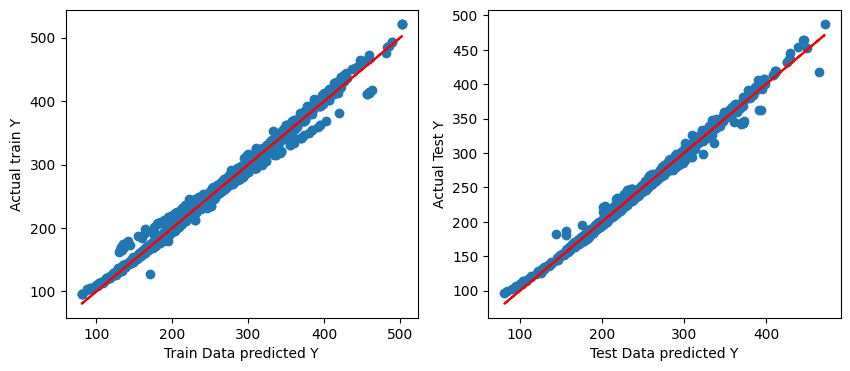

In [ ]:
fig,axes=plt.subplots(1,2,figsize= (10,4))
axes[0].scatter(Y_ols_train_pred,Y_ols_train)
axes[0].plot(Y_ols_train_pred,Y_ols_train_pred,'r')
axes[0].set_xlabel('Train Data predicted Y')
axes[0].set_ylabel('Actual train Y')

axes[1].scatter(Y_ols_test_pred,Y_ols_test)
axes[1].plot(Y_ols_test_pred,Y_ols_test_pred,'r')
axes[1].set_xlabel('Test Data predicted Y')
axes[1].set_ylabel('Actual Test Y')

plt.show()

From the above graph the actual target vs predicted target values is linear. We furthur check using rainbow test.

In [ ]:
linear_rainbow(res=ols_model,frac=0.5)

(np.float64(0.7603110139997247), np.float64(0.9999999999996696))

Here, p-value (0.999) is larger than 0.05. So it clearly indicates Linear model is fine.

#### 2. Multicollinearity

In [ ]:
X_ols_train_scaled_df = pd.DataFrame(X_ols_train_scaled,columns=X_ols_train_encoded.columns)

In [ ]:
vif=pd.DataFrame()
vif['features'] = X_ols_train_scaled_df.columns

In [ ]:
vif['VIF']=[variance_inflation_factor(X_ols_train_scaled_df.values,i) for i in range(X_ols_train_scaled_df.shape[1])]

In [ ]:
vif.sort_values(by='VIF',ascending=False)

,features,VIF
7,Fuel Consumption Comb (L/100 km),4727.644365
5,Fuel Consumption City (L/100 km),2108.954488
6,Fuel Consumption Hwy (L/100 km),578.036596
12,Fuel Type_Z,12.660060
11,Fuel Type_X,12.512207
3,Engine Size(L),9.918672
8,Fuel Consumption Comb (mpg),9.688892
4,Cylinders,9.583389
1,Model,7.691097
9,Fuel Type_E,5.660352


In [ ]:
X_vif= X_ols_train_scaled_df.copy()

In [ ]:
while vif['VIF'].max() > 10:
  high_vif_col=vif.sort_values(by='VIF',ascending=False).iloc[0,0]
  X_vif=X_vif.drop(high_vif_col,axis=1)
  vif=pd.DataFrame()
  vif['features']=X_vif.columns
  vif['VIF']=[variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

vif


,features,VIF
0,Make,1.812739
1,Model,5.981916
2,Vehicle Class,1.839116
3,Engine Size(L),9.657183
4,Cylinders,8.952502
5,Fuel Consumption Comb (mpg),5.283802
6,Fuel Type_E,1.362159
7,Fuel Type_N,1.001726
8,Fuel Type_X,1.382541
9,Transmission_Without_Gear_AM,1.455637


#### 3. Normality

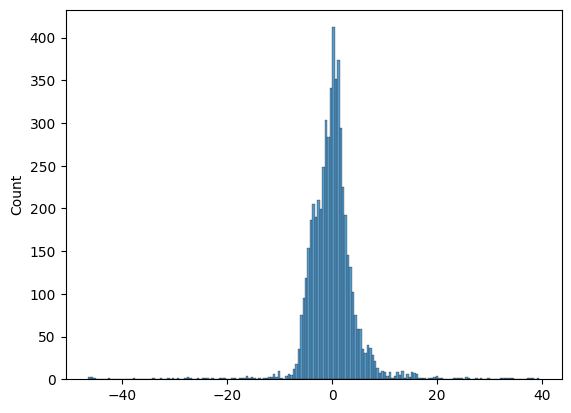

In [ ]:
sns.histplot(ols_model.resid)
plt.show()

From the above chart it is very clear that the error distibution is normally distributed across zero.

#### 4. Autocorelation (Independence of errors)

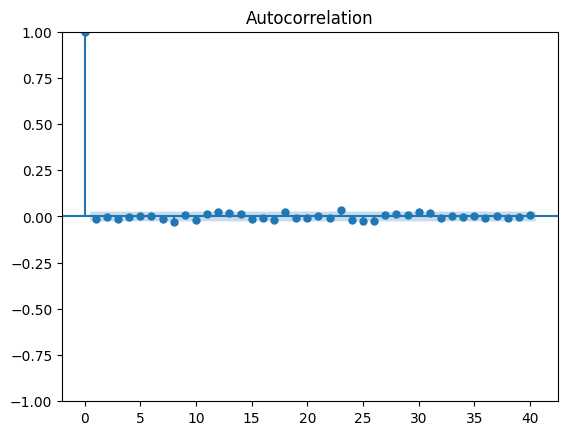

In [ ]:
import statsmodels.tsa.api as smt
acf = smt.graphics.plot_acf(ols_model.resid, lags=40 , alpha=0.05)
acf.show()

From the above ACF(auto correlation function) plot we can see there are almost all residulat points compared from current time slot to previous time slots which falls within confidence interval (95%) which means **there is no autocorrelation** between the residuals between current and previous time slot.

#### 5.  Homoscadacity : variance test

In [ ]:
Y_ols_train_residuals = Y_ols_train - Y_ols_train_pred.reshape(-1,1)

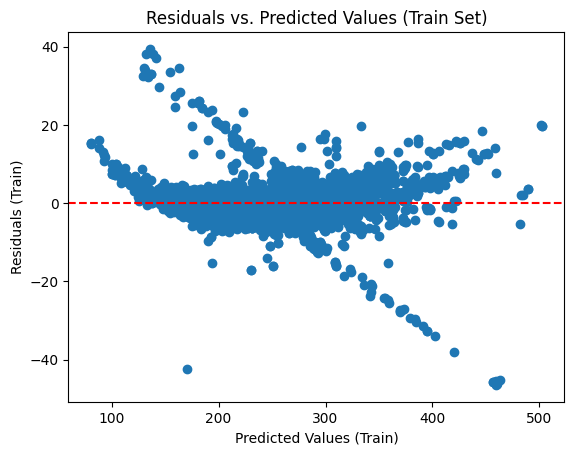

In [ ]:
plt.scatter(Y_ols_train_pred,Y_ols_train_residuals)
plt.title('Residuals vs. Predicted Values (Train Set)')
plt.xlabel('Predicted Values (Train)')
plt.ylabel('Residuals (Train)')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

In [ ]:
Y_ols_test_residuals=Y_ols_test - Y_ols_test_pred.reshape(-1,1)

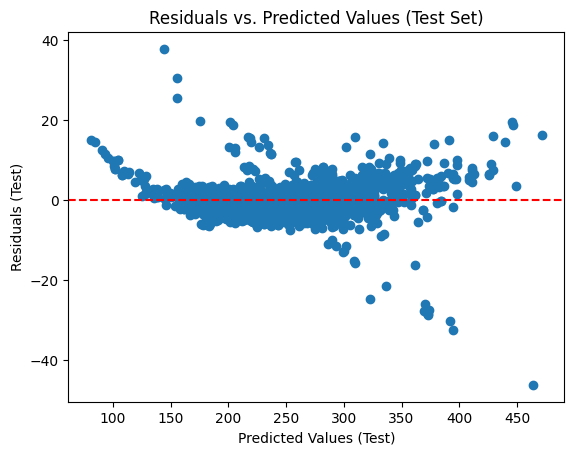

In [ ]:
plt.scatter(Y_ols_test_pred,Y_ols_test_residuals)
plt.title('Residuals vs. Predicted Values (Test Set)')
plt.xlabel('Predicted Values (Test)')
plt.ylabel('Residuals (Test)')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

From the above 2 graphs it looks like Homoscadacity assumption is failing since there is a funeal like pattern visible which shows that the residual increases/decreases with predicted values.

In [ ]:
test=sms.het_goldfeldquandt(y=Y_ols_train_residuals,x=X_ols_train_scaled_constant)
test

(np.float64(0.9947168996005904), np.float64(0.555242832172028), 'increasing')

**Goldfeld-Quandt test** shows a higher p-value (0.55) which is > 0.05.This means the test fails to reject the null hypothesis and conclude that the variance of residual is constant. **Heteroscedasticity is not present.**

In [ ]:
feature_score=pd.DataFrame({
    'feature': X_ols_train.columns,
    'coeficient': np.abs(ols_model.params[1:])
})
feature_score.sort_values(by='coeficient',ascending=False)

,feature,coeficient
x10,Fuel Type_E,29.213311
x8,Fuel Consumption Comb (L/100 km),23.848035
x6,Fuel Consumption City (L/100 km),20.913384
x13,Fuel Type_Z,14.864548
x12,Fuel Type_X,14.538136
x7,Fuel Consumption Hwy (L/100 km),11.428191
x9,Fuel Consumption Comb (mpg),6.535415
x5,Cylinders,1.887046
x11,Fuel Type_N,1.467270
x2,Model,1.231054


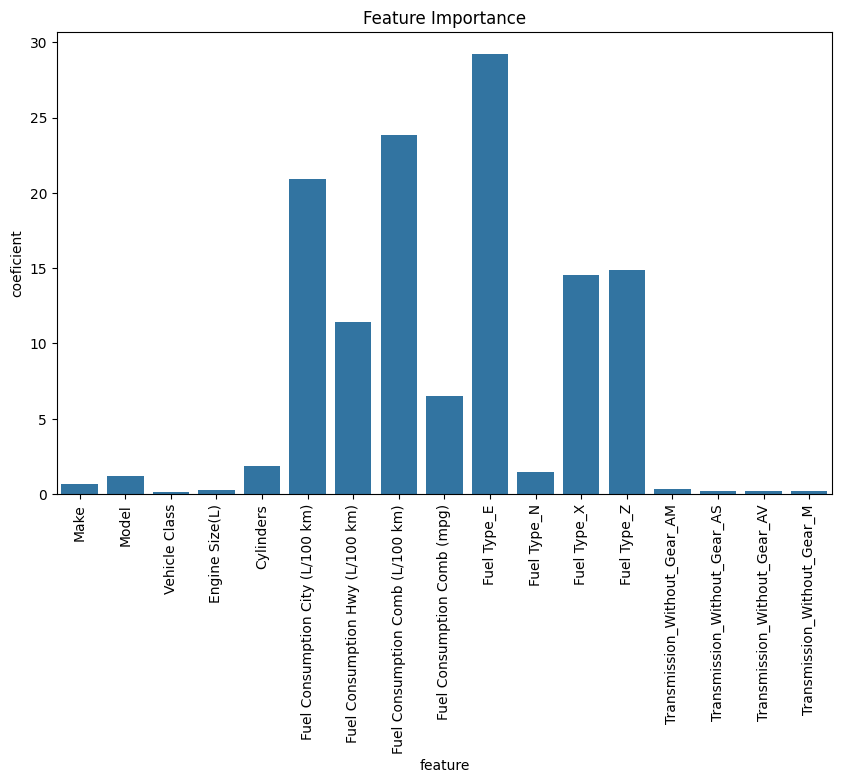

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='feature',y='coeficient',data=feature_score)
plt.title('Feature Importance')
plt.xticks(rotation=90)
plt.show()

From above Feature Importance graph it is evident that the 2 catagory of features - **Fuel Consumption** and **Fuel Type** have stronger influence on the target (CO2 emission)

In [ ]:
X_Y_df=pd.concat([X_ols_train_scaled_df,Y_ols_train],axis=1)

In [ ]:
X_Y_df.columns

Index(['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
       'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)',
       'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)',
       'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z',
       'Transmission_Without_Gear_AM', 'Transmission_Without_Gear_AS',
       'Transmission_Without_Gear_AV', 'Transmission_Without_Gear_M',
       'CO2 Emissions(g/km)'],
      dtype='object')

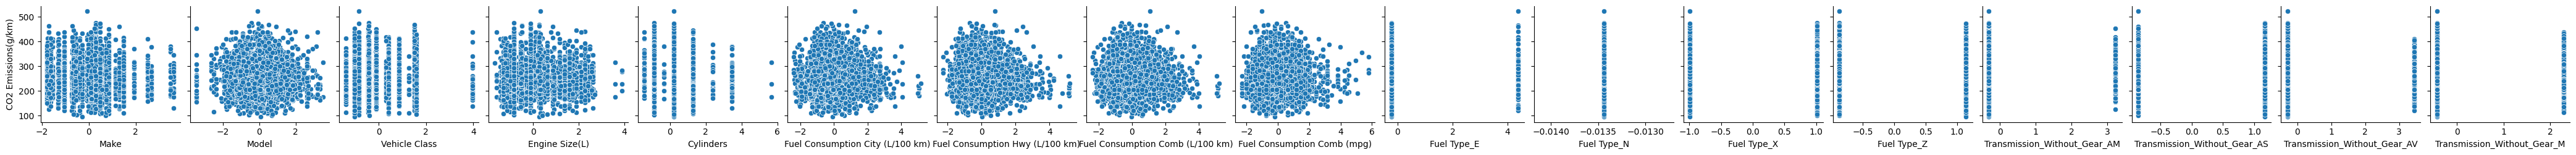

In [ ]:
# plt.figure(figsize=(14,10))
sns.pairplot(X_Y_df,x_vars=X_ols_train_scaled_df.columns,y_vars=['CO2 Emissions(g/km)'])

In [ ]:
corr_matrix_df=X_Y_df.corr()
corr_matrix_df

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Transmission_Without_Gear_AM,Transmission_Without_Gear_AS,Transmission_Without_Gear_AV,Transmission_Without_Gear_M,CO2 Emissions(g/km)
Make,1.000000,0.578485,0.355828,0.563253,0.606672,0.589218,0.521041,0.572431,-0.550264,0.141536,0.006377,-0.295676,0.220058,0.057751,0.005450,-0.238139,-0.217147,-0.027464
Model,0.578485,1.000000,0.625613,0.803470,0.775565,0.866155,0.850362,0.870872,-0.855380,0.143363,-0.005655,-0.254249,0.197062,0.000404,0.095342,-0.306434,-0.222934,-0.020282
Vehicle Class,0.355828,0.625613,1.000000,0.515491,0.442929,0.573829,0.645037,0.605639,-0.543305,0.221023,-0.011335,-0.024149,-0.087758,-0.045842,-0.017414,-0.164430,-0.200650,-0.024253
Engine Size(L),0.563253,0.803470,0.515491,1.000000,0.928873,0.833138,0.767164,0.820056,-0.762874,0.161303,0.004426,-0.234106,0.185871,-0.018053,0.016312,-0.194415,-0.200933,-0.014889
Cylinders,0.606672,0.775565,0.442929,0.928873,1.000000,0.801496,0.715581,0.781076,-0.721841,0.111564,0.002778,-0.311806,0.280948,0.045079,0.048894,-0.200701,-0.191749,-0.014556
Fuel Consumption City (L/100 km),0.589218,0.866155,0.573829,0.833138,0.801496,1.000000,0.948541,0.993853,-0.927618,0.447502,0.010187,-0.316073,0.156028,-0.021382,0.047537,-0.330954,-0.165710,-0.025266
Fuel Consumption Hwy (L/100 km),0.521041,0.850362,0.645037,0.767164,0.715581,0.948541,1.000000,0.977458,-0.893223,0.480130,0.002773,-0.251617,0.079275,-0.025979,0.029789,-0.253081,-0.193478,-0.025342
Fuel Consumption Comb (L/100 km),0.572431,0.870872,0.605639,0.820056,0.781076,0.993853,0.977458,1.000000,-0.926834,0.463908,0.008044,-0.297125,0.130927,-0.022820,0.041073,-0.307731,-0.177014,-0.025820
Fuel Consumption Comb (mpg),-0.550264,-0.855380,-0.543305,-0.762874,-0.721841,-0.927618,-0.893223,-0.926834,1.000000,-0.322660,-0.010283,0.302463,-0.199322,0.039723,-0.098407,0.398821,0.162161,0.013841
Fuel Type_E,0.141536,0.143363,0.221023,0.161303,0.111564,0.447502,0.480130,0.463908,-0.322660,1.000000,-0.003072,-0.226204,-0.199320,-0.062173,-0.054341,-0.066406,-0.090830,-0.019814
